#***Importing Libraries***

In [ ]:
import re #removing URLs and punctuation
import string #getting lists of punctuation characters like !"#$%&'()*+
import pandas as pd #load and process the CSV data in a DataFrame.
import nltk #Imports the Natural Language Toolkit, a powerful library for working with human language data.
from nltk.corpus import stopwords #Imports the collection of common "filler" words to be removed (e.g., "the," "is," "a").
from nltk.stem import WordNetLemmatizer #Imports the tool used to reduce words to their base or dictionary form (e.g., "running" becomes "run").
from nltk.sentiment.vader import SentimentIntensityAnalyzer #A pre-trained tool used to determine if a piece of text is positive, negative, or neutral.
from sklearn.model_selection import train_test_split # Splits your data into two sets: one for training the machine model and one for testing it.
from sklearn.feature_extraction.text import TfidfVectorizer # Converts text into numbers based on word importance
from sklearn.naive_bayes import MultinomialNB # used specifically for classifying text (like Spam vs. Not Spam).
from sklearn.metrics import classification_report, accuracy_score # Tools to calculate how well the model performed.
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
try:
    nltk.download('wordnet', quiet=True) #Downloads the WordNet lexical database, which is required for the WordNetLemmatizer.
    nltk.download('stopwords', quiet=True) #the comprehensive list of English stopwords.
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english')) #Loads the English stopwords into a highly efficient set data structure for quick lookups.
    use_nltk = True #Sets a flag indicating that NLTK resources were successfully loaded and should be used.
except Exception:
    # Minimal stopword list fallback if NLTK cannot download resources
    stop_words = {'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers', 'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', 'couldn', 'didn', 'doesn', 'hadn', 'hasn', 'haven', 'isn', 'ma', 'mightn', 'mustn', 'needn', 'shan', 'shouldn', 'wasn', 'weren', 'won', 'wouldn'}
    lemmatizer = None
    use_nltk = False
    print("WARNING: Could not load NLTK resources. Using basic stopword list and skipping lemmatization.")
# If the download fails, it initializes a minimal fallback stopword list and sets lemmatizer = None and use_nltk = False

#***Data Loading and Cleaning***

In [ ]:
#load dataset into dataframe
df = pd.read_csv("TikTok.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460287 entries, 0 to 460286
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   reviewId  460287 non-null  object
 1   content   460256 non-null  object
 2   score     460287 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 10.5+ MB


In [ ]:
# checking for missing values and duplicates
print(df.isnull().sum())
print(df.duplicated().sum())

reviewId     0
content     31
score        0
dtype: int64
0


In [ ]:
# Handling missing values
df.dropna(subset=['content'], inplace=True)
df.reset_index(drop=True, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460256 entries, 0 to 460255
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   reviewId  460256 non-null  object
 1   content   460256 non-null  object
 2   score     460256 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 10.5+ MB


#***Data Preprocessing***

In [ ]:

# Define Custom Stopwords
# Words like 'TikTok' and 'app' are common to all reviews and should be removed
custom_stopwords = {'tiktok', 'tik', 'tok', 'tik tok', 'tik-tok', 'app','get','dont','im','make','account','video','please','people','time','really'}
final_stop_words = stop_words.union(custom_stopwords)


def clean_text_with_custom_stopwords(text):
    # 1. Convert to Lowercase
    text = str(text).lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove punctuation and non-alphabetic characters (including numbers and most emojis)
    # The regex [^a-zA-Z\s] is effective for removing symbols, numbers, and most emojis.
    text = re.sub(r'[^a-zA-Z\s]', '', text)


    tokens = text.split()


    # 4. Lemmatization (only if NLTK was successfully imported)
    if use_nltk and lemmatizer:
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
    # 5. Stopword Removal (using the final combined list)
    tokens = [word for word in tokens if word not in final_stop_words and len(word) > 1]

    # 6. Reconstruct the cleaned text
    return " ".join(tokens)

# Apply the enhanced cleaning function
df['cleaned_content_final'] = df['content'].apply(clean_text_with_custom_stopwords)

# Display a sample of the results
print("Original vs. Final Cleaned Content Samples:")
print(df[['content', 'cleaned_content_final']].head())

Original vs. Final Cleaned Content Samples:
                                             content  \
0                                           No words   
1                              Great fun app so far!   
2  The app would get a higher rating but I litera...   
3  I WISH I COULD GIVE THIS A 100 PERCENT RATING ...   
4                                Pictures and record   

                               cleaned_content_final  
0                                               word  
1                                      great fun far  
2  would higher rating literally cant sign second...  
3                wish could give percent rating love  
4                                     picture record  


#***VADER***

In [ ]:
# Download VADER lexicon
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    print("Downloading VADER lexicon...")
    nltk.download('vader_lexicon', quiet=True)

# Initialize the VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to get VADER scores
def get_vader_scores(text):
    if pd.isna(text) or str(text).strip() == '':
        return {'compound': 0.0, 'neg': 0.0, 'neu': 1.0, 'pos': 0.0}
    return analyzer.polarity_scores(str(text))

# Apply the VADER analysis to the cleaned text
df['vader_scores'] = df['cleaned_content_final'].apply(get_vader_scores)

# Extract the compound score
df['vader_compound'] = df['vader_scores'].apply(lambda x: x['compound'])

# Define classification function based on VADER compound score
# Thresholds are standard for VADER:
# Positive: score >= 0.05
# Neutral: -0.05 < score < 0.05
# Negative: score <= -0.05
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply the classification
df['VADER_Sentiment'] = df['vader_compound'].apply(classify_sentiment)

# Display the first few rows showing the new columns
print("VADER Sentiment Analysis Results:")
print(df[['content', 'cleaned_content_final', 'score', 'vader_compound', 'VADER_Sentiment']].head(10))


VADER Sentiment Analysis Results:
                                             content  \
0                                           No words   
1                              Great fun app so far!   
2  The app would get a higher rating but I litera...   
3  I WISH I COULD GIVE THIS A 100 PERCENT RATING ...   
4                                Pictures and record   
5                            I love this amazing app   
6                                     Mohammed Rehan   
7                             Love being on Tik Tok.   
8                        Kwai pelo menos da dinheiro   
9  Post to view is such a step backwards for the ...   

                               cleaned_content_final  score  vader_compound  \
0                                               word      5          0.0000   
1                                      great fun far      5          0.8126   
2  would higher rating literally cant sign second...      1         -0.2975   
3                wish could give 

In [ ]:
# Print distribution of VADER sentiment
sentiment_counts = df['VADER_Sentiment'].value_counts(normalize=True).mul(100).round(2)
print("\nOverall VADER Sentiment Distribution (%):")
print(sentiment_counts)


Overall VADER Sentiment Distribution (%):
VADER_Sentiment
Positive    64.93
Neutral     27.77
Negative     7.30
Name: proportion, dtype: float64


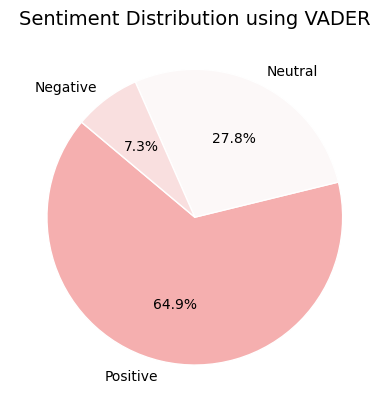

In [ ]:
sentiment_colors = {'Positive': '#F5AFAF', 'Negative': '#F9DFDF', 'Neutral': '#FCF8F8'}

# 2. Sentiment VADER Pie Chart
plt.clf()
sentiment_counts = df['VADER_Sentiment'].value_counts()
labels = sentiment_counts.index
colors = [sentiment_colors[label] for label in labels]
plt.pie(sentiment_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor': 'white'})
plt.title('Sentiment Distribution using VADER', fontsize=14)
plt.savefig('sentiment_pie.png', bbox_inches='tight')

#***Machine Model***

##***Labeling***

In [ ]:

# Target Label Creation (Mapping 5-star score to 3 sentiment classes)
# Positive: 4, 5 stars
# Neutral: 3 stars
# Negative: 1, 2 stars
def create_sentiment_label(score):
    if score >= 4:
        return 'Positive'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['True_Sentiment'] = df['score'].apply(create_sentiment_label)





##***Split the data into training and testing data***

In [ ]:
# Filter out empty cleaned reviews before training
df_model = df[df['cleaned_content_final'].str.strip() != ''].copy()

X = df_model['cleaned_content_final']
y = df_model['True_Sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


##***TF-IDF***

In [ ]:
tfidf = TfidfVectorizer(max_features=5000) # Limiting features to top 5000 for efficiency
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

##***Multinomial Naive Bayes***

In [ ]:
# Model Training (Multinomial Naive Bayes)
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Prediction and Evaluation
y_pred = nb_model.predict(X_test_tfidf)

# Generate Classification Report
report = classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive'], output_dict=True)

print("Classification Model Performance (Multinomial Naive Bayes):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(pd.DataFrame(report).transpose())

# Store predicted sentiment in the full DataFrame for a complete output file
df['Predicted_Sentiment'] = 'N/A' # Initialize new column
df.loc[df_model.index, 'Predicted_Sentiment'] = nb_model.predict(tfidf.transform(df_model['cleaned_content_final']))


Classification Model Performance (Multinomial Naive Bayes):
Accuracy: 0.8439

              precision    recall  f1-score       support
Negative       0.641504  0.483839  0.551627  14139.000000
Neutral        0.280000  0.001982  0.003936   3532.000000
Positive       0.872573  0.961283  0.914782  68677.000000
accuracy       0.843864  0.843864  0.843864      0.843864
macro avg      0.598026  0.482368  0.490115  86348.000000
weighted avg   0.810498  0.843864  0.818060  86348.000000


In [ ]:
print(df[['VADER_Sentiment', 'Predicted_Sentiment']].head(10))

  VADER_Sentiment Predicted_Sentiment
0         Neutral            Positive
1        Positive            Positive
2        Negative            Negative
3        Positive            Positive
4         Neutral            Positive
5        Positive            Positive
6         Neutral            Positive
7        Positive            Positive
8         Neutral            Positive
9        Negative            Negative


In [ ]:
df.to_csv('output.csv', index=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460256 entries, 0 to 460255
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   reviewId               460256 non-null  object 
 1   content                460256 non-null  object 
 2   score                  460256 non-null  int64  
 3   cleaned_content_final  460256 non-null  object 
 4   vader_scores           460256 non-null  object 
 5   vader_compound         460256 non-null  float64
 6   VADER_Sentiment        460256 non-null  object 
 7   True_Sentiment         460256 non-null  object 
 8   Predicted_Sentiment    460256 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 31.6+ MB


##***Comparison between testing and training data accuracy***

In [ ]:
y_train_pred = nb_model.predict(X_train_tfidf)
train_accuracy = accuracy_score(y_train, y_train_pred)

y_test_pred = nb_model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("         Accuracy Comparison")
print(f"Accuracy on Training Data: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Accuracy on Testing Data:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


         Accuracy Comparison
Accuracy on Training Data: 0.8466 (84.66%)
Accuracy on Testing Data:  0.8439 (84.39%)


<Figure size 640x480 with 0 Axes>

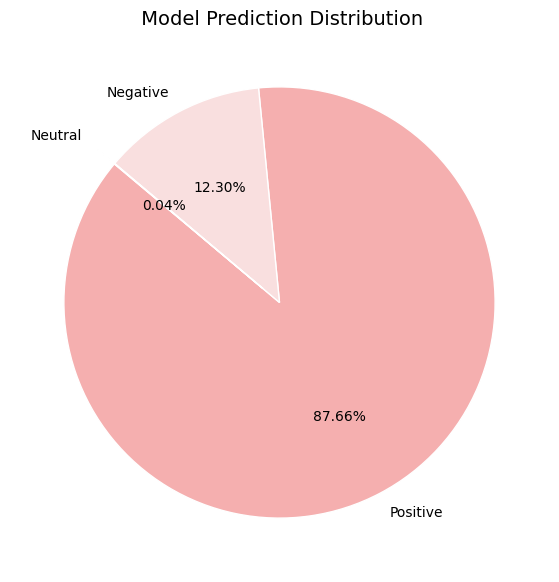

In [ ]:

# 2. Count the predictions
counts = df[df['Predicted_Sentiment'] != 'N/A']['Predicted_Sentiment'].value_counts()

plt.clf()
plt.figure(figsize=(10, 7))

# We use 2 decimal places (%1.2f) to show the tiny Neutral percentage
labels = counts.index
colors = [sentiment_colors.get(label, '#999999') for label in labels]

plt.pie(
    counts,
    labels=labels,
    autopct='%1.2f%%', # Increased to 2 decimal places
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white'},
    explode=[0.1 if label == 'Neutral' else 0 for label in labels] # Pop out the 'Neutral' slice
)

plt.title(' Model Prediction Distribution', fontsize=14)
plt.show()

#***Visualizations***

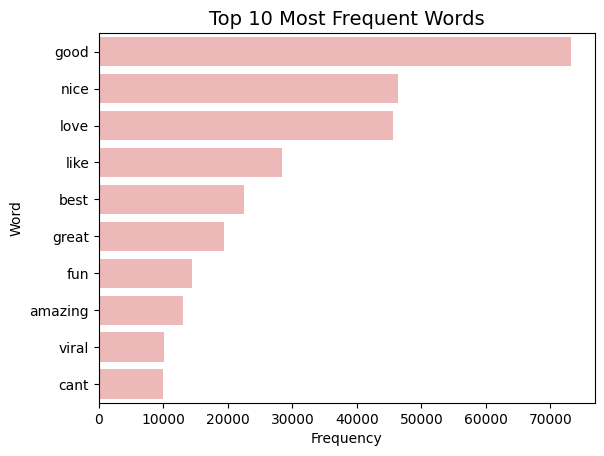

In [ ]:
# Styling
color_main = '#F5AFAF'
sentiment_colors = {'Positive': '#F5AFAF', 'Negative': '#F9DFDF', 'Neutral': '#FCF8F8'}

# 1. Word Graph: Top 10 Frequent Words
plt.clf()
all_words = ' '.join(df_model['cleaned_content_final'].astype(str)).split()
word_counts = Counter(all_words).most_common(10)
words_df = pd.DataFrame(word_counts, columns=['Word', 'Frequency'])
sns.barplot(x='Frequency', y='Word', data=words_df, color=color_main)
plt.title('Top 10 Most Frequent Words', fontsize=14)
plt.savefig('word_frequency.png', bbox_inches='tight')

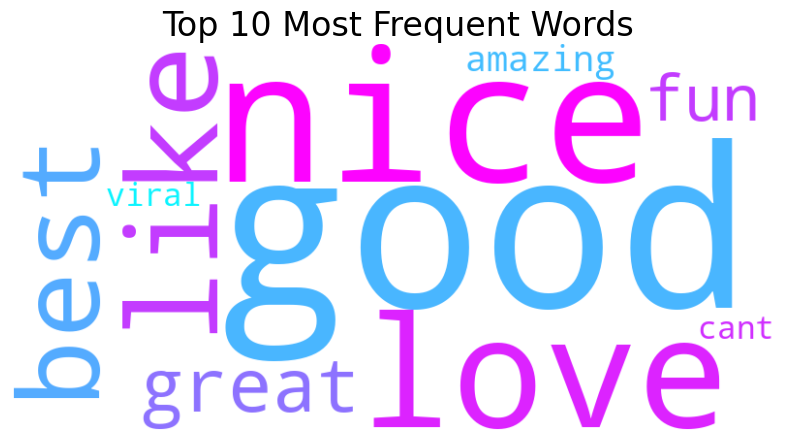

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Plot a word cloud with color map
def plot_word_cloud(word_freq):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='cool'
    ).generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Top 10 Most Frequent Words', fontsize=24)
    plt.show()

# Create word_freq dictionary from word_counts
word_freq = dict(word_counts)
plot_word_cloud(word_freq)

In [ ]:
df_model.info()
df_model.head()

<class 'pandas.core.frame.DataFrame'>
Index: 431740 entries, 0 to 460255
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   reviewId               431740 non-null  object 
 1   content                431740 non-null  object 
 2   score                  431740 non-null  int64  
 3   cleaned_content_final  431740 non-null  object 
 4   vader_scores           431740 non-null  object 
 5   vader_compound         431740 non-null  float64
 6   VADER_Sentiment        431740 non-null  object 
 7   True_Sentiment         431740 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 29.6+ MB


,reviewId,content,score,cleaned_content_final,vader_scores,vader_compound,VADER_Sentiment,True_Sentiment
0,68ccaec8-1415-4301-a85e-3004679a3a83,No words,5,word,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,Neutral,Positive
1,d84cbfd3-6aa3-485c-aaf9-c5dca27dc966,Great fun app so far!,5,great fun far,"{'neg': 0.0, 'neu': 0.119, 'pos': 0.881, 'comp...",0.8126,Positive,Positive
2,96618aa1-31e5-4259-8649-89b75d962f00,The app would get a higher rating but I litera...,1,would higher rating literally cant sign second...,"{'neg': 0.079, 'neu': 0.877, 'pos': 0.044, 'co...",-0.2975,Negative,Negative
3,078c0bda-598b-474e-a04e-d7cb3e6f6301,I WISH I COULD GIVE THIS A 100 PERCENT RATING ...,5,wish could give percent rating love,"{'neg': 0.0, 'neu': 0.367, 'pos': 0.633, 'comp...",0.7845,Positive,Positive
4,8e68c5cd-b12a-4206-a8da-6bfdbff44ae3,Pictures and record,5,picture record,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,Neutral,Positive


<Figure size 640x480 with 0 Axes>

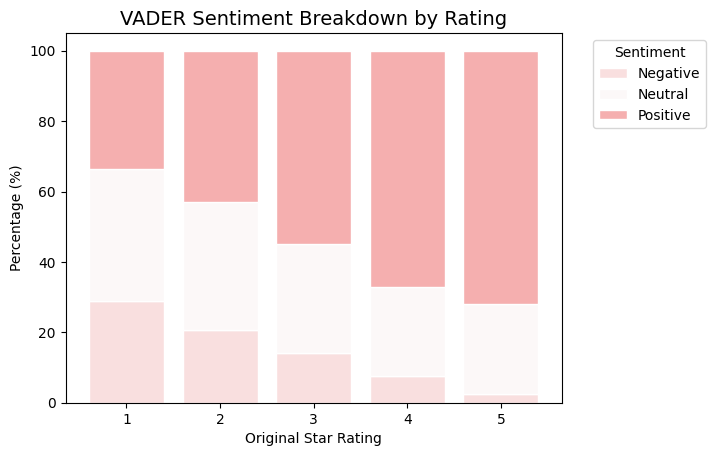

In [ ]:
plt.clf()
pivot_df = pd.crosstab(df['score'], df['VADER_Sentiment'], normalize='index') * 100
cols = [c for c in ['Negative', 'Neutral', 'Positive'] if c in pivot_df.columns]
pivot_df = pivot_df[cols]
pivot_df.plot(kind='bar', stacked=True, color=[sentiment_colors[c] for c in cols], edgecolor='white', width=0.8)
plt.title('VADER Sentiment Breakdown by Rating', fontsize=14)
plt.xlabel('Original Star Rating')
plt.ylabel('Percentage (%)')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

<Figure size 640x480 with 0 Axes>

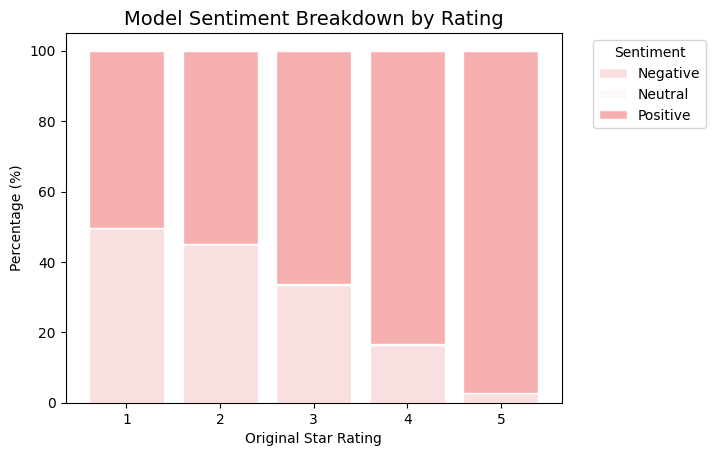

In [ ]:
plt.clf()
pivot_df = pd.crosstab(df_model['score'], df['Predicted_Sentiment'], normalize='index') * 100
cols = [c for c in ['Negative', 'Neutral', 'Positive'] if c in pivot_df.columns]
pivot_df = pivot_df[cols]
pivot_df.plot(kind='bar', stacked=True, color=[sentiment_colors[c] for c in cols], edgecolor='white', width=0.8)
plt.title('Model Sentiment Breakdown by Rating', fontsize=14)
plt.xlabel('Original Star Rating')
plt.ylabel('Percentage (%)')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()